## 모델 사용
https://huggingface.co/nlp04/korean_sentiment_analysis_kcelectra?library=transformers

In [1]:
!pip install transformers
!pip install sentencepiece
!pip install wordcloud
!pip install konlpy
!pip install matplotlib seaborn


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.4/19.4 MB 67.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 494.1/494.1 kB 25.9 MB/s eta 0:00:00


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from konlpy.tag import Okt
from transformers import pipeline, AutoTokenizer, AutoModelForSequenceClassification
from transformers import PreTrainedTokenizerFast, BartForConditionalGeneration
from google.colab import files


In [3]:
uploaded = files.upload()  # sbs_preproces.csv 업로드
df = pd.read_csv("sbs_preproces.csv")
df = df.dropna(subset=['Content']).reset_index(drop=True)
print("데이터 크기:", df.shape)
df.head()


Saving sbs_preproces.csv to sbs_preproces.csv
데이터 크기: (47, 8)


,Date,Title,Url,Content,Google_noti,Xml_url,Content_tokens,Content_tokens_no_stop
0,"March 24, 2025 at 01:10PM","최여진, 7세 연상 '돌싱' 예비 남편 논란 입 열까""방송으로 확인"" 공식 - 한국경제",https://www.hankyung.com/article/2025032431187,... SBS &39;동상이몽2-너는 내 운명&39; 제작진이 방송 확인을 당부했다...,Google 알리미 - sbs,https://www.google.com/alerts/feeds/0409998130...,"['...', 'SBS', '&', '39', ';', '동상', '이몽', '2'...","['...', 'SBS', '&', '39', ';', '동상', '이몽', '2'..."
1,"March 24, 2025 at 01:17PM","TREASURE트레저 'YELLOW', HIGHER 주간 SBS 인기가요 핫스테이지...",https://sports.khan.co.kr/article/202503241314003,제1260회 SBS 인기가요 핫스테이지 영광의 1위는 &39;TREASURE트레저&...,Google 알리미 - sbs,https://www.google.com/alerts/feeds/0409998130...,"['제', '1260회', 'SBS', '인기가요', '핫', '스테이지', '영광...","['제', '1260회', 'SBS', '인기가요', '핫', '스테이지', '영광..."
2,"March 24, 2025 at 01:19PM","TREASURE트레저 'YELLOW', HIGHER 주간 SBS 인기가요 핫스테이지...",https://news.nate.com/view/20250324n19221?mid=...,한눈에 보는 오늘 : 연예가 화제 - 뉴스 : 사진제공 | HIGHER하이어제126...,Google 알리미 - sbs,https://www.google.com/alerts/feeds/0409998130...,"['한눈', '에', '보다', '오늘', ':', '연예', '가', '화제', ...","['한눈', '보다', '오늘', ':', '연예', '화제', '-', '뉴스',..."
3,"March 24, 2025 at 01:53PM","가수 최유리, SBS '애프터클럽' 새 DJ 합류 - 브릿지경제",https://www.viva100.com/article/20250324500598,가수 최유리가 SBS &39;애프터클럽&39;의 새 DJ로 찾아온다. 24일 SBS...,Google 알리미 - sbs,https://www.google.com/alerts/feeds/0409998130...,"['가수', '최유리', '가', 'SBS', '&', '39', ';', '애프터...","['가수', '최유리', 'SBS', '&', '39', ';', '애프터', '클..."
4,"March 24, 2025 at 06:18PM","한덕수 복귀하자 최상목 활짝 웃으며 ""드디어"" 현장영상 / SBS - YouTube",https://www.youtube.com/watch?v=7JS45Bp8bIc,... sbs.co.kr/y/t/?id=10000000121 SBS뉴스 뉴스영상 총...,Google 알리미 - sbs,https://www.google.com/alerts/feeds/0409998130...,"['...', 'sbs.co.kr/y/t/?id=10000000121', 'SBS'...","['...', 'sbs.co.kr/y/t/?id=10000000121', 'SBS'..."


In [6]:
# KoELECTRA 감정 분석 모델 로드

# Use a pipeline as a high-level helper
from transformers import pipeline

pipe = pipeline("text-classification", model="nlp04/korean_sentiment_analysis_kcelectra")

# Load model directly
from transformers import AutoTokenizer, AutoModelForSequenceClassification

tokenizer = AutoTokenizer.from_pretrained("nlp04/korean_sentiment_analysis_kcelectra")
model = AutoModelForSequenceClassification.from_pretrained("nlp04/korean_sentiment_analysis_kcelectra")

# 감정 분석 적용
def get_sentiment(text):
    try:
        result = sentiment_pipeline(str(text)[:512])[0]
        return pd.Series([result['label'], result['score']])
    except:
        return pd.Series(['UNKNOWN', 0.0])

df[['sentiment', 'sentiment_score']] = df['Content'].apply(get_sentiment)

# 라벨 매핑 (LABEL_0 → NEGATIVE 등)
label_map = {
    'LABEL_0': 'NEGATIVE',
    'LABEL_1': 'NEUTRAL',
    'LABEL_2': 'POSITIVE'
}
df['sentiment'] = df['sentiment'].map(label_map)
df[['Content', 'sentiment', 'sentiment_score']].head()


config.json:   0%|          | 0.00/1.87k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/511M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/450k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/511M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.31M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

Device set to use cuda:0


,Content,sentiment,sentiment_score
0,... SBS &39;동상이몽2-너는 내 운명&39; 제작진이 방송 확인을 당부했다...,NaN,0.0
1,제1260회 SBS 인기가요 핫스테이지 영광의 1위는 &39;TREASURE트레저&...,NaN,0.0
2,한눈에 보는 오늘 : 연예가 화제 - 뉴스 : 사진제공 | HIGHER하이어제126...,NaN,0.0
3,가수 최유리가 SBS &39;애프터클럽&39;의 새 DJ로 찾아온다. 24일 SBS...,NaN,0.0
4,... sbs.co.kr/y/t/?id=10000000121 SBS뉴스 뉴스영상 총...,NaN,0.0


In [7]:
# 요약 모델 로드
tokenizer = PreTrainedTokenizerFast.from_pretrained("digit82/kobart-summarization")
model = BartForConditionalGeneration.from_pretrained("digit82/kobart-summarization")

def summarize_kobart(text):
    try:
        input_ids = tokenizer.encode(str(text), return_tensors='pt', max_length=512, truncation=True)
        summary_ids = model.generate(input_ids, max_length=45, min_length=10, do_sample=False)
        return tokenizer.decode(summary_ids[0], skip_special_tokens=True)
    except:
        return "[요약 실패]"

df['summary'] = df['Content'].apply(summarize_kobart)
df[['Content', 'summary']].head()


tokenizer_config.json:   0%|          | 0.00/295 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/682k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/109 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.20k [00:00<?, ?B/s]

You passed along `num_labels=3` with an incompatible id to label map: {'0': 'NEGATIVE', '1': 'POSITIVE'}. The number of labels will be overwritten to 2.


pytorch_model.bin:   0%|          | 0.00/496M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/496M [00:00<?, ?B/s]

,Content,summary
0,... SBS &39;동상이몽2-너는 내 운명&39; 제작진이 방송 확인을 당부했다...,SBS &39;동상이몽2-너는 내 운명&39; 제작진이 방송 확인을 당부하며 한경닷...
1,제1260회 SBS 인기가요 핫스테이지 영광의 1위는 &39;TREASURE트레저&...,제1260회 SBS 인기가요 핫스테이지 영광의 1위는 &39;TREASURE트레저&...
2,한눈에 보는 오늘 : 연예가 화제 - 뉴스 : 사진제공 | HIGHER하이어제126...,SBS 인기가요 핫스테이지 영광의 1위는 &39;TREASURE트레저&39;TREA...
3,가수 최유리가 SBS &39;애프터클럽&39;의 새 DJ로 찾아온다. 24일 SBS...,24일 SBS 파워FM에 따르면 다음달 7일부터 월요일 새벽마다 최유리가 &39;애...
4,... sbs.co.kr/y/t/?id=10000000121 SBS뉴스 뉴스영상 총...,"SBS 뉴스 뉴스 뉴스는 총리 한덕수 최상목 복귀, SBS 뉴스 채널 구독하기 : ..."


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 29 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128478 (\N{ROLLED-UP NEWSPAPER}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


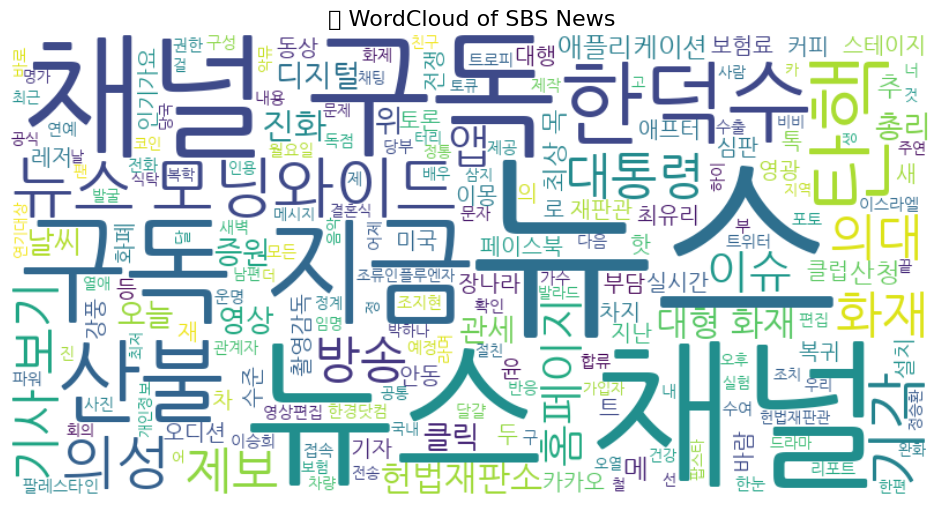

In [26]:
import matplotlib.pyplot as plt
import pandas as pd
from konlpy.tag import Okt
from wordcloud import WordCloud

# 나눔 폰트 설치
!apt-get install -y fonts-nanum
!fc-cache -fv
plt.rc('font', family='NanumGothic')

# 형태소 분석 기반 WordCloud 생성 코드
okt = Okt()

def extract_nouns(text):
    return ' '.join(okt.nouns(str(text)))

text_all = ' '.join(df['Content'].apply(extract_nouns).tolist())

wordcloud = WordCloud(font_path='/usr/share/fonts/truetype/nanum/NanumGothic.ttf',
                    width=800, height=400, background_color='white').generate(text_all)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("🗞 WordCloud of SBS News", fontsize=16)
plt.show()

<ipython-input-27-189954114559>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='sentiment', palette='pastel')
<ipython-input-27-189954114559>:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.countplot(data=df, x='sentiment', palette='pastel')
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49324 (\N{HANGUL SYLLABLE SA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  

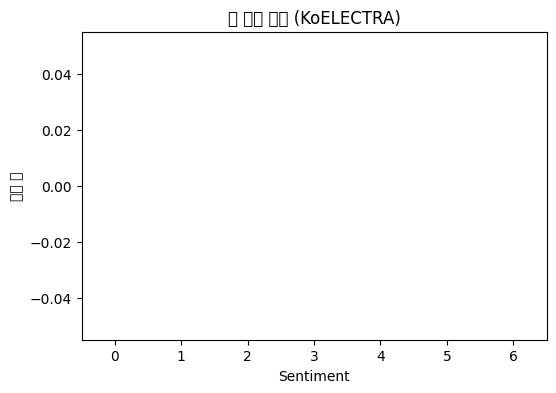

In [27]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='sentiment', palette='pastel')
plt.title("📊 감정 분포 (KoELECTRA)")
plt.xlabel("Sentiment")
plt.ylabel("기사 수")
plt.show()


In [12]:
df.to_csv("sbs_with_sentiment_summary.csv", index=False)
files.download("sbs_with_sentiment_summary.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 뉴스 요약비교

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# 파일 불러오기
df = pd.read_csv("/content/sbs_with_sentiment_summary.csv")

In [18]:
# 뉴스 요약 품질 평가: 요약 길이 비교
df['content_len'] = df['Content'].apply(lambda x: len(str(x).split()))
df['summary_len'] = df['summary'].apply(lambda x: len(str(x).split()))
df['summary_ratio'] = df['summary_len'] / df['content_len']


In [19]:
df[['content_len', 'summary_len', 'summary_ratio']].describe()
#summary_ratio가 0.9 이상이면 요약 실패 가능성 있음.-> 0.89라서 다시 한번 확인 해봐야할듯

,content_len,summary_len,summary_ratio
count,47.000000,47.000000,47.000000
mean,16.425532,14.468085,0.887118
std,2.551595,5.937541,0.337139
min,10.000000,2.000000,0.090909
25%,15.000000,12.500000,0.743421
50%,16.000000,14.000000,0.866667
75%,18.000000,16.000000,1.000000
max,22.000000,36.000000,1.857143


In [20]:
# 5개 기사 원문 vs 요약문 비교
for i, row in df.iterrows():
    print(f"\n📰 기사 #{i}:\n{row['Content']}\n")
    print(f"📝 요약문:\n{row['summary']}\n")
    print("="*80)



📰 기사 #0:
... SBS &39;동상이몽2-너는 내 운명&39; 제작진이 방송 확인을 당부했다. &39;동상이몽2&39; 측 관계자는 24일 한경닷컴에 &quot;모든 내용이 방송에 나올 예정&quot;이라며 &quot;방송으로&nbsp;...

📝 요약문:
SBS &39;동상이몽2-너는 내 운명&39; 제작진이 방송 확인을 당부하며 한경닷컴에 &quot;모든 내용이 방송에 나올 예정&quot;이라며 &qu


📰 기사 #1:
제1260회 SBS 인기가요 핫스테이지 영광의 1위는 &39;TREASURE트레저&39;가 차지했다. HIGHER 앱에 접속하면 TREASURE가 1위 트로피를 수여 받은 독점 포토를&nbsp;...

📝 요약문:
제1260회 SBS 인기가요 핫스테이지 영광의 1위는 &39;TREASURE트레저&39;TREASURE트레저&39;


📰 기사 #2:
한눈에 보는 오늘 : 연예가 화제 - 뉴스 : 사진제공 | HIGHER하이어제1260회 SBS 인기가요 핫스테이지 영광의 1위는 &39;TREASURE트레저&39;가 차지했다.

📝 요약문:
SBS 인기가요 핫스테이지 영광의 1위는 &39;TREASURE트레저&39;TREASURE트레저&39;TREAS


📰 기사 #3:
가수 최유리가 SBS &39;애프터클럽&39;의 새 DJ로 찾아온다. 24일 SBS 파워FM에 따르면 다음달 7일부터 월요일 새벽마다 최유리가 &39;애프터클럽&39;의 DJ로 합류한다.

📝 요약문:
24일 SBS 파워FM에 따르면 다음달 7일부터 월요일 새벽마다 최유리가 &39;애프터클럽&39;의 새 DJ로 찾아온다고 밝혔다.


📰 기사 #4:
... sbs.co.kr/y/t/?id=10000000121 SBS뉴스 뉴스영상 총리 한덕수 최상목 복귀 ▷SBS 뉴스 채널 구독하기 : https://n.sbs.co.kr/youtube ♨지금&nbsp;...

📝 요약문:
SBS 뉴스 뉴스 뉴스는 총리 한덕수 최상목 복귀, SBS 뉴스 채널 구독하기 : https://n

In [21]:
# 완전 동일한 요약문
same_summary = df[df['Content'].str.strip() == df['summary'].str.strip()]
print(f"❗ 원문과 요약이 동일한 기사 수: {len(same_summary)}")

# 요약 길이 비율이 0.9 이상 → 복사 가능성 높은 기사
similar_summary = df[df['summary_ratio'] > 0.9]
print(f"❗ 요약이 거의 원문과 동일한 기사 수: {len(similar_summary)}")


❗ 원문과 요약이 동일한 기사 수: 0
❗ 요약이 거의 원문과 동일한 기사 수: 21


## 감정 분석 품질 평가

In [23]:
# 1, 데이터 불러오기

import pandas as pd

df=pd.read_csv("/content/sbs_with_sentiment_summary.csv")

In [24]:
#2. 감정 점수 컬럼 확인
if 'sentiment_score' in df.columns:
    print("sentiment_score 컬럼이 존재합니다.")
else:
    print("sentiment_score 컬럼이 존재하지 않습니다.")

sentiment_score 컬럼이 존재합니다.


<ipython-input-25-7e79a93492dc>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sentiment', data=df, palette='pastel')
<ipython-input-25-7e79a93492dc>:6: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.countplot(x='sentiment', data=df, palette='pastel')
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


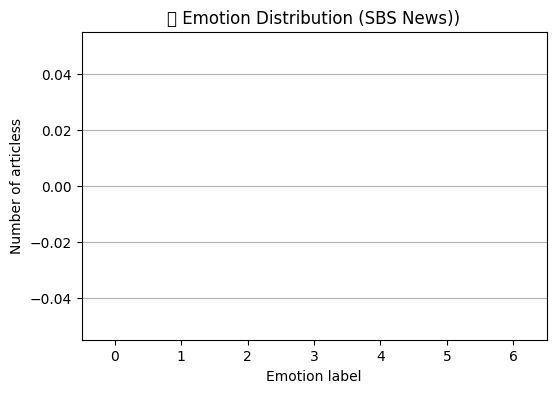

In [25]:
# 감정 분포 시각화
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))
sns.countplot(x='sentiment', data=df, palette='pastel')
plt.title("📊 Emotion Distribution (SBS News))")
plt.xlabel("Emotion label")
plt.ylabel("Number of articless")
plt.grid(axis='y')
plt.show()

In [28]:
# ✅ 4. 감정 예측 샘플 확인 (내용 + 감정)
sample_df = df.sample(5, random_state=42)

for i, row in sample_df.iterrows():
    print(f"\n📰 기사 #{i}:\n{row['Content']}")
    print(f"💬 예측 감정: {row['sentiment']}", end="")

    if 'sentiment_score' in df.columns:
        print(f" (신뢰도: {row['sentiment_score']:.2f})")
    else:
        print()
    print("="*80)



📰 기사 #27:
메가MGC커피가 오는 4월 9일까지 공식 애플리케이션앱에서 &39;2025 SBS 메가 콘서트&39;메가콘 2차 티켓 이벤트를 진행한다.지난달 메가MGC커피는 2025 SBS&nbsp;...
💬 예측 감정: nan (신뢰도: 0.00)

📰 기사 #39:
... sbs.co.kr/y/?id=N1008033893 SBS뉴스 모닝와이드 기각 한덕수 헌법재판소 탄핵소추 총리 직무복귀 ▷SBS 뉴스 채널 구독하기 : https://n.sbs&nbsp;...
💬 예측 감정: nan (신뢰도: 0.00)

📰 기사 #26:
&39;우리들의 발라드&39;는 악뮤, 정승환, 비비, 카더가든 등을 발굴한 &39;K팝스타&39;, &39;더 팬&39; 등 국내 정통 오디션의 명가 SBS에서 선보이는 새로운 음악 오디션으로,&nbsp;...
💬 예측 감정: nan (신뢰도: 0.00)

📰 기사 #43:
... sbs.co.kr/y/?id=N1008033929 ☞의대 증원 기사 모아보기 https://news.sbs.co.kr/y/i/?id=10000057872 SBS뉴스 실시간 의대 연세대 증원 제적 ▷SBS&nbsp;...
💬 예측 감정: nan (신뢰도: 0.00)

📰 기사 #24:
... sbs.co.kr/y/?id=N1008033351 ☞오!클릭 기사 모아보기 https://news.sbs.co.kr/y/t/?id=10000000168 SBS뉴스 오클릭 산불 ▷SBS 뉴스 채널 구독하기&nbsp;...
💬 예측 감정: nan (신뢰도: 0.00)


In [29]:
# ✅ 5. 감정 점수가 낮은 기사만 확인 (선택)
if 'sentiment_score' in df.columns:
    low_conf_df = df[df['sentiment_score'] < 0.6]
    print(f"🔍 감정 신뢰도 낮은 기사 수: {len(low_conf_df)}")

    # 예시 출력
    display(low_conf_df[['Content', 'sentiment', 'sentiment_score']].head())


🔍 감정 신뢰도 낮은 기사 수: 47


,Content,sentiment,sentiment_score
0,... SBS &39;동상이몽2-너는 내 운명&39; 제작진이 방송 확인을 당부했다...,NaN,0.0
1,제1260회 SBS 인기가요 핫스테이지 영광의 1위는 &39;TREASURE트레저&...,NaN,0.0
2,한눈에 보는 오늘 : 연예가 화제 - 뉴스 : 사진제공 | HIGHER하이어제126...,NaN,0.0
3,가수 최유리가 SBS &39;애프터클럽&39;의 새 DJ로 찾아온다. 24일 SBS...,NaN,0.0
4,... sbs.co.kr/y/t/?id=10000000121 SBS뉴스 뉴스영상 총...,NaN,0.0
